In [3]:
###################
#RHC Example

#install packages (if needed)
install.packages("tableone")
install.packages("ipw")
install.packages("sandwich")
install.packages("survey")

#load packages
library(tableone)
library(ipw)
library(sandwich) #for robust variance estimation
library(survey)

expit <- function(x) {1/(1+exp(-x)) }
logit <- function(p) {log(p)-log(1-p)}

#read in data
# load(url("http://biostat.mc.vanderbilt.edu/wiki/pub/Main/DataSets/rhc.sav"))
load(url("https://hbiostat.org/data/repo/rhc.sav"))
#view data
View(rhc)

#treatment variables is swang1
#x variables that we will use
#cat1: primary disease category
#age
#sex
#meanbp1: mean blood pressure

#create a data set with just these variables, for simplicity
ARF<-as.numeric(rhc$cat1=='ARF')
CHF<-as.numeric(rhc$cat1=='CHF')
Cirr<-as.numeric(rhc$cat1=='Cirrhosis')
colcan<-as.numeric(rhc$cat1=='Colon Cancer')
Coma<-as.numeric(rhc$cat1=='Coma')
COPD<-as.numeric(rhc$cat1=='COPD')
lungcan<-as.numeric(rhc$cat1=='Lung Cancer')
MOSF<-as.numeric(rhc$cat1=='MOSF w/Malignancy')
sepsis<-as.numeric(rhc$cat1=='MOSF w/Sepsis')
female<-as.numeric(rhc$sex=='Female')
died<-as.integer(rhc$death=='Yes')
age<-rhc$age
treatment<-as.numeric(rhc$swang1=='RHC')
meanbp1<-rhc$meanbp1

#new dataset
mydata<-cbind(ARF,CHF,Cirr,colcan,Coma,lungcan,MOSF,sepsis,
              age,female,meanbp1,treatment,died)
mydata<-data.frame(mydata)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



,cat1,cat2,ca,sadmdte,dschdte,dthdte,lstctdte,death,cardiohx,chfhx,⋯,meta,hema,seps,trauma,ortho,adld3p,urin1,race,income,ptid
,<fct>,<fct>,<fct>,<labelled>,<labelled>,<labelled>,<labelled>,<fct>,<labelled>,<labelled>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<labelled>,<labelled>,<fct>,<fct>,<labelled>
1,COPD,NA,Yes,11142,11151,NA,11382,No,0,0,⋯,No,No,No,No,No,0,NA,white,Under $11k,00005
2,MOSF w/Sepsis,NA,No,11799,11844,11844,11844,Yes,1,1,⋯,No,No,Yes,No,No,NA,1437,white,Under $11k,00007
3,MOSF w/Malignancy,MOSF w/Sepsis,Yes,12083,12143,NA,12400,No,0,0,⋯,No,No,No,No,No,NA,599,white,$25-$50k,00009
4,ARF,NA,No,11146,11183,11183,11182,Yes,0,0,⋯,No,No,No,No,No,NA,NA,white,$11-$25k,00010
5,MOSF w/Sepsis,NA,No,12035,12037,12037,12036,Yes,0,0,⋯,No,No,No,No,No,NA,64,white,Under $11k,00011
6,COPD,NA,No,12389,12396,NA,12590,No,0,1,⋯,No,No,No,No,No,0,242,white,Under $11k,00012
7,MOSF w/Malignancy,NA,Metastatic,12381,12423,NA,12616,No,0,0,⋯,No,No,No,No,No,NA,4465,white,$25-$50k,00013
8,ARF,Coma,No,11453,11487,11491,11490,Yes,0,0,⋯,No,No,Yes,No,No,NA,NA,white,$25-$50k,00014
9,MOSF w/Malignancy,NA,Yes,12426,12437,NA,12560,No,0,0,⋯,No,Yes,No,No,No,NA,5525,white,Under $11k,00016


In [19]:
#covariates we will use (shorter list than you would use in practice)
xvars<-c("age","female","meanbp1","ARF","CHF","Cirr","colcan",
         "Coma","lungcan","MOSF","sepsis")

#look at a table 1
table1<- CreateTableOne(vars=xvars,strata="treatment", data=mydata, test=FALSE)
## include standardized mean difference (SMD)
print(table1,smd=TRUE)

#propensity score model
psmodel <- glm(treatment ~ age + female + meanbp1+ARF+CHF+Cirr+colcan+
         Coma+lungcan+MOSF+sepsis,
               family  = binomial(link ="logit"))

## value of propensity score for each subject
ps <-predict(psmodel, type = "response")

#create weights
weight<-ifelse(treatment==1,1/(ps),1/(1-ps))

#apply weights to data
weighteddata<-svydesign(ids = ~ 1, data =mydata, weights = ~ weight)

#weighted table 1
weightedtable <-svyCreateTableOne(vars = xvars, strata = "treatment", 
                                 data = weighteddata, test = FALSE)
## Show table with SMD
print(weightedtable, smd = TRUE)

                     Stratified by treatment
                      0             1             SMD   
  n                    3551          2184               
  age (mean (SD))     61.76 (17.29) 60.75 (15.63)  0.061
  female (mean (SD))   0.46 (0.50)   0.41 (0.49)   0.093
  meanbp1 (mean (SD)) 84.87 (38.87) 68.20 (34.24)  0.455
  ARF (mean (SD))      0.45 (0.50)   0.42 (0.49)   0.059
  CHF (mean (SD))      0.07 (0.25)   0.10 (0.29)   0.095
  Cirr (mean (SD))     0.05 (0.22)   0.02 (0.15)   0.145
  colcan (mean (SD))   0.00 (0.04)   0.00 (0.02)   0.038
  Coma (mean (SD))     0.10 (0.29)   0.04 (0.20)   0.207
  lungcan (mean (SD))  0.01 (0.10)   0.00 (0.05)   0.095
  MOSF (mean (SD))     0.07 (0.25)   0.07 (0.26)   0.018
  sepsis (mean (SD))   0.15 (0.36)   0.32 (0.47)   0.415
                     Stratified by treatment
                      0               1               SMD   
  n                   5732.49         5744.88               
  age (mean (SD))       61.36 (17.56)   61.43 (

In [9]:
# weighted mean (column 2, age weighted mean by brute force)
mean(weight[treatment==1]*age[treatment==1])/(mean(weight[treatment==1]))

[1] 61.42933

# MSM
psi 1 and psi 2

In [12]:
#get causal relative risk. Weighted GLM
glm.obj<-glm(died~treatment,weights=weight,family=quasibinomial(link=log))
#summary(glm.obj)
betaiptw<-coef(glm.obj)
#to properly account for weighting, use asymptotic (sandwich) variance
SE<-sqrt(diag(vcovHC(glm.obj, type="HC0")))

#get point estimate and CI for relative risk (need to exponentiate)
#   log[E(Ya)] = psi0 + psi1 a
#   exp(psi0) exp(psi1)^1 want exp(psi1)
causalrr<-exp(betaiptw[2])
# 95% conf interval
lcl<-exp(betaiptw[2]-1.96*SE[2])
ucl<-exp(betaiptw[2]+1.96*SE[2])
c(lcl,causalrr,ucl)

treatment treatment treatment 
 1.036698  1.081764  1.128790

In [13]:
#get causal risk difference
glm.obj<-glm(died~treatment,weights=weight,family=quasibinomial(link="identity"))
#summary(glm.obj)
betaiptw<-coef(glm.obj)
SE<-sqrt(diag(vcovHC(glm.obj, type="HC0")))

causalrd<-(betaiptw[2])
lcl<-(betaiptw[2]-1.96*SE[2])
ucl<-(betaiptw[2]+1.96*SE[2])
c(lcl,causalrd,ucl)

treatment  treatment  treatment 
0.02333223 0.05154951 0.07976679

In [14]:
#truncate weights at 10

truncweight<-replace(weight,weight>10,10)
#get causal risk difference
glm.obj<-glm(died~treatment,weights=truncweight,family=quasibinomial(link="identity"))
#summary(glm.obj)
betaiptw<-coef(glm.obj)
SE<-sqrt(diag(vcovHC(glm.obj, type="HC0")))

causalrd<-(betaiptw[2])
lcl<-(betaiptw[2]-1.96*SE[2])
ucl<-(betaiptw[2]+1.96*SE[2])
c(lcl,causalrd,ucl)

treatment  treatment  treatment 
0.02768882 0.05493243 0.08217605

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.046   1.405   1.721   2.001   2.280  21.606 

(Intercept)   treatment 
 0.63046375  0.05154951

,2.5 %,97.5 %
(Intercept),0.61401097,0.64691653
treatment,0.02332433,0.07977469


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.081   1.405   1.721   1.972   2.280   6.379 

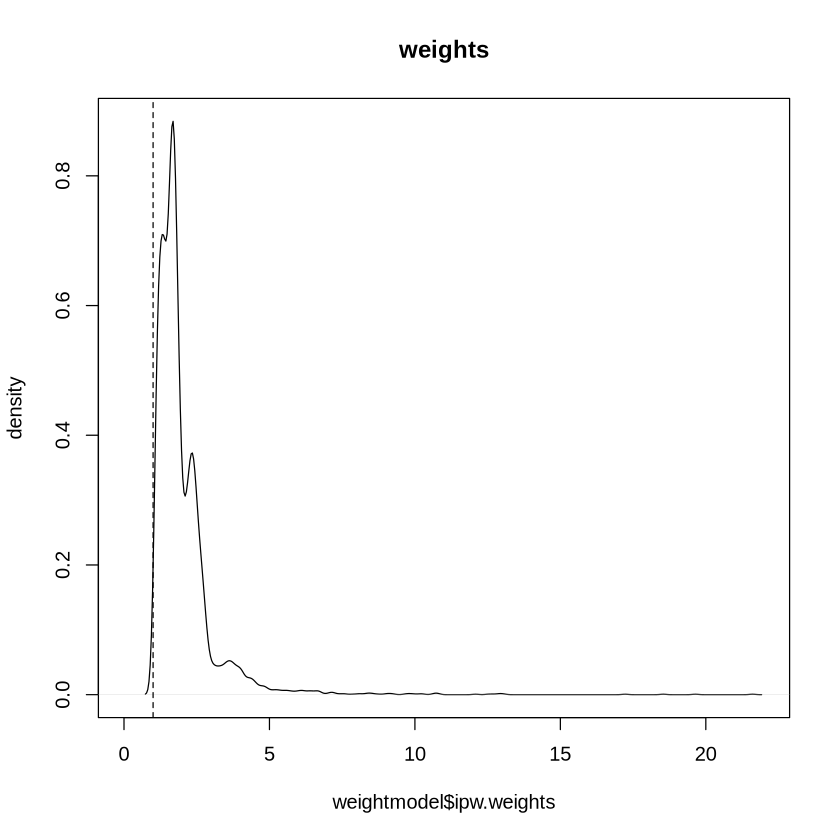

(Intercept)   treatment 
 0.63045533  0.05494865

,2.5 %,97.5 %
(Intercept),0.61400312,0.64690753
treatment,0.02822366,0.08167363


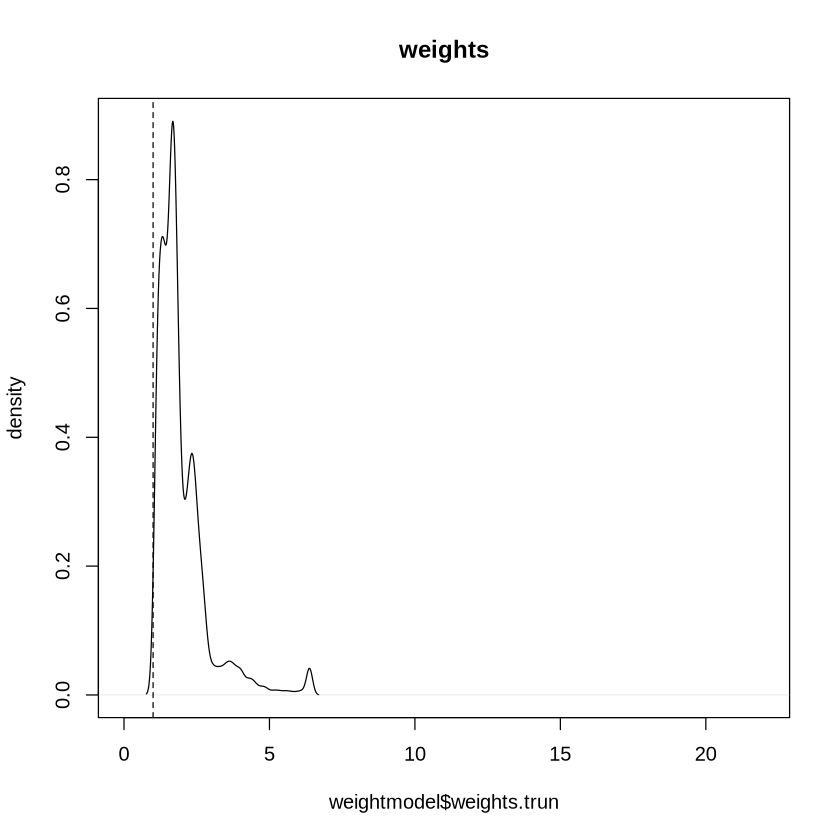

In [16]:
#############################
#alternative: use ipw package
#############################

#first fit propensity score model to get weights
weightmodel<-ipwpoint(exposure= treatment, family = "binomial", link ="logit",
          denominator= ~ age + female + meanbp1+ARF+CHF+Cirr+colcan+
           Coma+lungcan+MOSF+sepsis, data=mydata)
#numeric summary of weights
summary(weightmodel$ipw.weights)
#plot of weights
ipwplot(weights = weightmodel$ipw.weights, logscale = FALSE,
         main = "weights", xlim = c(0, 22))
mydata$wt<-weightmodel$ipw.weights

#fit a marginal structural model (risk difference)
msm <- (svyglm(died ~ treatment, design = svydesign(~ 1, weights = ~wt,
                  data =mydata)))
coef(msm)
confint(msm)


# fit propensity score model to get weights, but truncated
weightmodel<-ipwpoint(exposure= treatment, family = "binomial", link ="logit",
                      denominator= ~ age + female + meanbp1+ARF+CHF+Cirr+colcan+
                        Coma+lungcan+MOSF+sepsis, data=mydata,trunc=.01)

#numeric summary of weights
summary(weightmodel$weights.trun)
#plot of weights
ipwplot(weights = weightmodel$weights.trun, logscale = FALSE,
        main = "weights", xlim = c(0, 22))
mydata$wt<-weightmodel$weights.trun
#fit a marginal structural model (risk difference)
msm <- (svyglm(died ~ treatment, design = svydesign(~ 1, weights = ~wt,
                                                    data =mydata)))
coef(msm)
confint(msm)